# 05 — Warfield ISM-MICMAC and the Method Comparison

Places every package by driving power (transitive dependents) against dependence power
(transitive dependencies), then compares ten rankings (structural, popularity, learned,
hybrid). The only notebook that reloads registry-wide dependent counts — the second,
independent impact currency for the expected-impact circularity check.


## 1. Imports & config

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csgraph
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve)

from common import (BUCKET_ORDER, ECO_TITLES, MIN_PER_CLASS, MIN_VIEW_POS, SEED,
                    build_graph_structures, make_views, reach_weighted_sums,
                    read_csv_literal, to_bucket)

ECO       = os.environ.get("ECO", "npm")
ECO_TITLE = ECO_TITLES[ECO]

ROOT    = Path("..")
PREP    = ROOT / "data" / "output" / ECO / "01_data_prep"
NOISY   = ROOT / "data" / "output" / ECO / "04_noisy-or-sweep"
OUT_DIR = ROOT / "data" / "output" / ECO / "05_warfield_exploration"
OUT_DIR.mkdir(parents=True, exist_ok=True)

K_TABLE     = [100, 500, 1000, 2000, 5000]
TARGET_FPRS = [0.5, 0.3, 0.1, 0.05, 0.01, 0.001]
CLR_CLEAN, CLR_VULN, CLR_COMP = "#009e3a", "#eda100", "#e34948"

METHOD_STYLE = {
    "Random":                    ("#b0afa6", ":"),
    "In-degree":                 ("#85847c", "--"),
    "PageRank":                  ("#7b5ea7", "--"),
    "ISM driving power":         ("#008300", "-"),
    "Global dependents":         ("#2a78d6", "-"),
    "REI worst-case impact":     ("#e87ba4", "-"),
    "ML P(positive)":            ("#eda100", "-"),
    "Noisy-OR propagated":       ("#eb6834", "-"),
    "Expected impact (in-data)": ("#1baf7a", "-"),
    "Expected impact (registry)":("#c0392b", "-"),
}

t_nb = time.time()
print(f"{ECO_TITLE} | out: {OUT_DIR.resolve()}")


npm | out: C:\Users\amehs\Documents\ThesisAppendixVersion\data\output\npm\05_warfield_exploration


## 2. Load corpus, graph, scores

In [2]:
schema = json.loads((PREP / "schema.json").read_text(encoding="utf-8"))
df = read_csv_literal(PREP / "model_ready_dataset.csv")
gf = read_csv_literal(PREP / "graph_features.csv")
edges = read_csv_literal(PREP / "edges.csv")
gdep = read_csv_literal(PREP / "global_dependents.csv")
scores_in = read_csv_literal(NOISY / "base_scores.csv")
best_alpha = json.loads((NOISY / "best_alpha.json").read_text(encoding="utf-8"))["best_per_view"]

assert (df["package"] == gf["package"]).all() and (df["package"] == gdep["package"]).all()
N = len(df)
label_arr = df["label"].astype(int).to_numpy()
m_clean, m_vuln, m_comp = (label_arr == 0), (label_arr == -1), (label_arr == 1)
global_deps = gdep["global_dependents"].to_numpy(dtype=np.float64)

pos_of = {p: i for i, p in enumerate(df["package"])}
src = edges["source"].map(pos_of).to_numpy(dtype=np.int64)
tgt = edges["target"].map(pos_of).to_numpy(dtype=np.int64)
conn_pkg = gf["connected"].to_numpy(dtype=bool)
in_degree = gf["in_degree"].to_numpy(dtype=np.float64)
pagerank = gf["pagerank"].to_numpy(dtype=np.float64)

VIEWS = make_views(label_arr, restrict_to=set(scores_in["view"]))

print(f"{ECO_TITLE}: {N:,} packages | {len(src):,} edges | views {list(VIEWS)}")
print(f"real-world dependents known for {int((global_deps>0).sum()):,} packages "
      f"(reloaded for this notebook only — the second impact currency)")

npm: 101,350 packages | 388,416 edges | views ['compromised', 'risky']
real-world dependents known for 99,930 packages (reloaded for this notebook only — the second impact currency)


## 3. ISM reachability — driving and dependence power

In [3]:
gs = build_graph_structures(src, tgt, N)
n_scc, scc, lev, topo = gs["n_scc"], gs["scc"], gs["lev"], gs["topo"]
scc_size = np.bincount(scc, minlength=n_scc).astype(np.float64)
level_pkg = lev[scc]

# popularity weight for the Simchi-Levi REI: 1 + log1p(registry direct dependents)
w_pop_scc = np.bincount(scc, weights=1.0 + np.log1p(np.maximum(global_deps, 0)), minlength=n_scc)
drive = reach_weighted_sums(gs["inf_csr"].indptr, gs["inf_csr"].indices, topo[::-1],
                            np.stack([scc_size, w_pop_scc], axis=1), label="driving")
depnd = reach_weighted_sums(gs["dep_csr"].indptr, gs["dep_csr"].indices, topo,
                            scc_size[:, None], label="dependence")
driving_power    = drive[scc, 0] - 1.0
impact_pop       = drive[scc, 1]           # popularity-weighted mass at risk, includes self
dependence_power = (depnd[:, 0] - 1.0)[scc]
rei_worstcase    = impact_pop / impact_pop.max()

bucket_pkg = np.array([to_bucket(l, not c) for l, c in zip(level_pkg, conn_pkg)])

print(f"SCCs {n_scc:,} | max level {int(lev.max())} | "
      f"driving power max {int(driving_power.max()):,} | "
      f"dependence power max {int(dependence_power.max()):,}")


  reachability [driving] 38.0s
  reachability [dependence] 35.8s
SCCs 100,415 | max level 151 | driving power max 12,875 | dependence power max 1,650


## 4. The MICMAC map

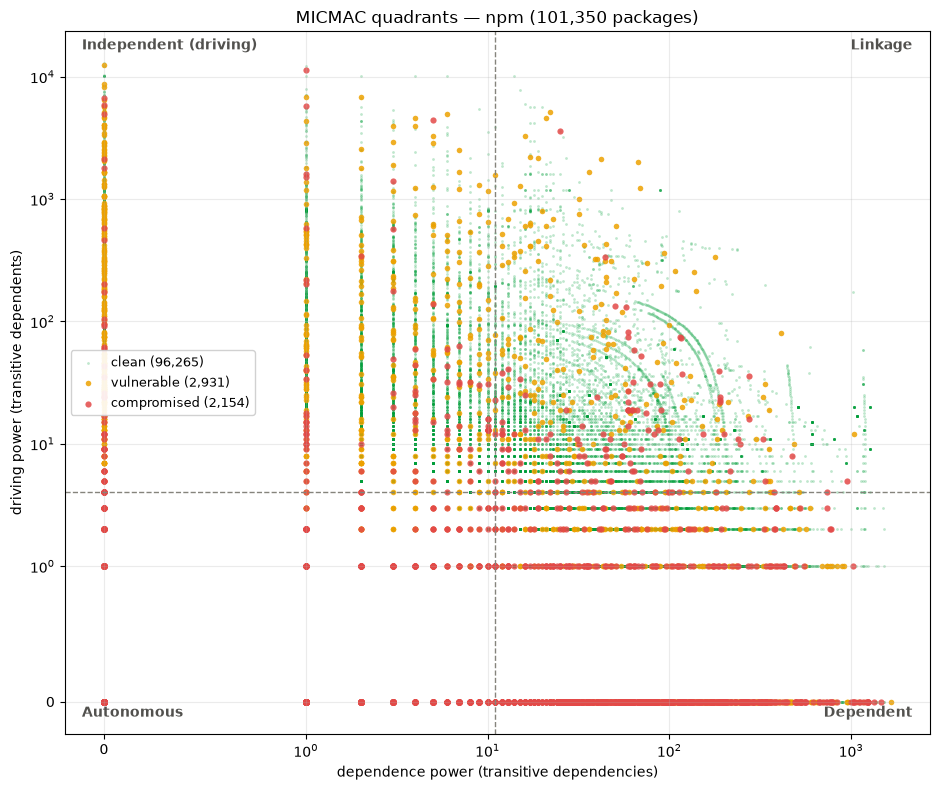

       view              quadrant     n  n_positive  pct_positive  lift_vs_base
compromised Independent (driving) 16155         126         0.780         0.356
compromised               Linkage  8391         125         1.490         0.681
compromised             Dependent 26634         936         3.514         1.606
compromised            Autonomous 31728         438         1.380         0.631
compromised              Isolated 15511         529         3.410         1.558
      risky Independent (driving) 16752         723         4.316         0.860
      risky               Linkage  8644         378         4.373         0.872
      risky             Dependent 27590        1892         6.858         1.367
      risky            Autonomous 32293        1003         3.106         0.619
      risky              Isolated 16071        1089         6.776         1.351


In [4]:
q_dep = float(np.median(dependence_power[dependence_power > 0])) if (dependence_power > 0).any() else 0.0
q_drv = float(np.median(driving_power[driving_power > 0])) if (driving_power > 0).any() else 0.0

fig, ax = plt.subplots(figsize=(9.5, 8))
for m, c, s, lab in [(m_clean, CLR_CLEAN, 4, "clean"), (m_vuln, CLR_VULN, 16, "vulnerable"),
                     (m_comp, CLR_COMP, 20, "compromised")]:
    if m.sum():
        ax.scatter(dependence_power[m], driving_power[m], s=s, c=c,
                   alpha=0.25 if lab == "clean" else 0.85, linewidths=0,
                   rasterized=True, label=f"{lab} ({int(m.sum()):,})")
ax.set_xscale("symlog", linthresh=1); ax.set_yscale("symlog", linthresh=1)
ax.axvline(q_dep, color="#85847c", ls="--", lw=1); ax.axhline(q_drv, color="#85847c", ls="--", lw=1)
ax.set_xlabel("dependence power (transitive dependencies)")
ax.set_ylabel("driving power (transitive dependents)")
for txt, xy, ha, va in [("Independent (driving)", (0.02, 0.99), "left", "top"),
                        ("Linkage", (0.98, 0.99), "right", "top"),
                        ("Autonomous", (0.02, 0.02), "left", "bottom"),
                        ("Dependent", (0.98, 0.02), "right", "bottom")]:
    ax.text(*xy, txt, transform=ax.transAxes, fontsize=10, fontweight="bold",
            color="#52514e", ha=ha, va=va)
ax.legend(loc="center left", fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25)
ax.set_title(f"MICMAC quadrants — {ECO_TITLE} ({N:,} packages)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "micmac_quadrants.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

quadrant = np.where(~conn_pkg, "Isolated",
           np.where((driving_power >= q_drv) & (dependence_power >= q_dep), "Linkage",
           np.where(driving_power >= q_drv, "Independent (driving)",
           np.where(dependence_power >= q_dep, "Dependent", "Autonomous"))))
QUAD_ORDER = ["Independent (driving)", "Linkage", "Dependent", "Autonomous", "Isolated"]
rows = []
for vname, v in VIEWS.items():
    y_full = np.zeros(N); y_full[np.flatnonzero(v["keep"])] = v["y"]
    prev = y_full[v["keep"]].mean()
    for q in QUAD_ORDER:
        m = (quadrant == q) & v["keep"]
        n_q = int(m.sum())
        rate = float(y_full[m].mean()) if n_q else np.nan
        rows.append({"view": vname, "quadrant": q, "n": n_q,
                     "n_positive": int(y_full[m].sum()),
                     "pct_positive": 100 * rate if n_q else np.nan,
                     "lift_vs_base": rate / prev if n_q and prev > 0 else np.nan})
quad_df = pd.DataFrame(rows)
quad_df.to_csv(OUT_DIR / "micmac_quadrant_composition.csv", index=False)
print(quad_df.to_string(index=False, float_format="{:.3f}".format))

## 5. Warfield level structure

       view level_bucket     n  n_positive  pct_positive
compromised     isolated 15511         529         3.410
compromised            0 14431          98         0.679
compromised            1 15185         236         1.554
compromised            2  9317         118         1.267
compromised            3  7986          96         1.202
compromised            4  5752          90         1.565
compromised          5-9 17681         520         2.941
compromised        10-19 10949         434         3.964
compromised          20+  1607          33         2.054
      risky     isolated 16071        1089         6.776
      risky            0 14822         489         3.299
      risky            1 15553         604         3.883
      risky            2  9561         362         3.786
      risky            3  8176         286         3.498
      risky            4  5891         229         3.887
      risky          5-9 18106         945         5.219
      risky        10-19 11542 

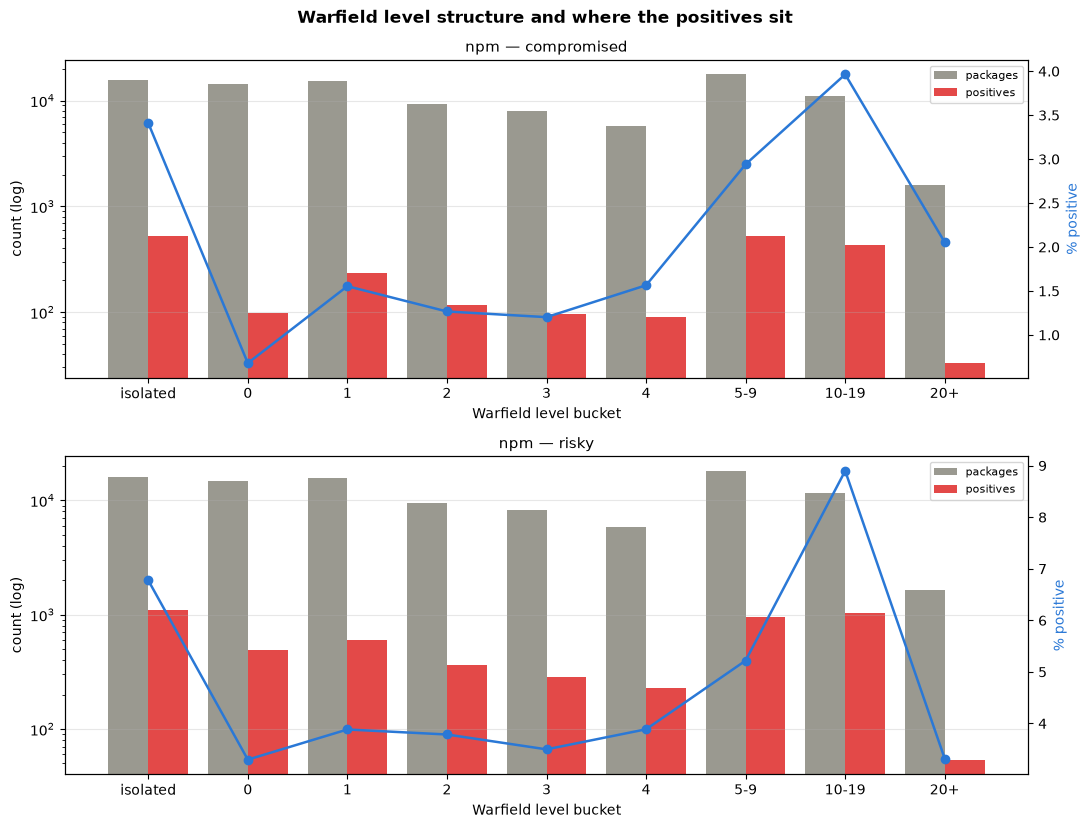

In [5]:
lv_rows = []
for vname, v in VIEWS.items():
    y_full = np.zeros(N); y_full[np.flatnonzero(v["keep"])] = v["y"]
    for b in BUCKET_ORDER:
        m = (bucket_pkg == b) & v["keep"]
        n_b = int(m.sum())
        lv_rows.append({"view": vname, "level_bucket": b, "n": n_b,
                        "n_positive": int(y_full[m].sum()),
                        "pct_positive": 100 * float(y_full[m].mean()) if n_b else np.nan})
lv_stats = pd.DataFrame(lv_rows)
lv_stats.to_csv(OUT_DIR / "warfield_level_stats.csv", index=False)
print(lv_stats.to_string(index=False, float_format="{:.3f}".format))

n_v = len(VIEWS)
fig, axes = plt.subplots(n_v, 1, figsize=(11, 4.2 * n_v), squeeze=False)
xb = np.arange(len(BUCKET_ORDER))
for i, vname in enumerate(VIEWS):
    ax = axes[i][0]
    s = lv_stats[lv_stats.view == vname].set_index("level_bucket").reindex(BUCKET_ORDER)
    ax.bar(xb - 0.2, s["n"], 0.4, color="#9a9990", label="packages")
    ax.bar(xb + 0.2, s["n_positive"], 0.4, color=CLR_COMP, label="positives")
    ax.set_yscale("log"); ax.set_ylabel("count (log)")
    ax2 = ax.twinx()
    ax2.plot(xb, s["pct_positive"], color="#2a78d6", marker="o", lw=1.8, label="% positive")
    ax2.set_ylabel("% positive", color="#2a78d6")
    ax.set_xticks(xb); ax.set_xticklabels(BUCKET_ORDER); ax.set_xlabel("Warfield level bucket")
    ax.set_title(f"{ECO_TITLE} — {vname}", fontsize=11); ax.legend(fontsize=8, loc="upper right")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Warfield level structure and where the positives sit", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "warfield_levels.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 6. The method roster

In [6]:
tiebreak = np.random.default_rng(SEED).permutation(N)
def ranking(score):
    # ties are massive on structural scores; one shared fixed-seed permutation breaks them
    return np.lexsort((tiebreak, -np.asarray(score, dtype=np.float64)))

random_score = np.random.default_rng(SEED).random(N)

METHODS_BY_VIEW = {}
for vname, v in VIEWS.items():
    s = scores_in[scores_in.view == vname].set_index("package")
    base = df["package"].map(s["base"]).to_numpy(dtype=np.float64)
    prop = df["package"].map(s["prop"]).to_numpy(dtype=np.float64)
    ei_ds = base * (1.0 + driving_power)
    ei_rw = base * (1.0 + global_deps)
    M = {
        "Random": random_score,
        "In-degree": in_degree,
        "PageRank": pagerank,
        "ISM driving power": driving_power,
        "Global dependents": global_deps,
        "REI worst-case impact": rei_worstcase,
        "ML P(positive)": base,
        "Expected impact (in-data)": ei_ds,
        "Expected impact (registry)": ei_rw,
    }
    if best_alpha[vname]["propagation_recommended"]:
        M["Noisy-OR propagated"] = prop
    METHODS_BY_VIEW[vname] = M
    print(f"[{vname}] {len(M)} methods"
          + ("" if best_alpha[vname]["propagation_recommended"]
             else "  (Noisy-OR excluded: notebook 04 did not recommend propagation here)"))

[compromised] 10 methods
[risky] 10 methods


## 7. Primary evaluation

In [7]:
def tpr_at_fpr(y_true, y_score, targets):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return {t: float(np.interp(t, fpr, tpr)) for t in targets}


metric_rows, curves = [], {}
for vname, v in VIEWS.items():
    keep = v["keep"]; y = v["y"]
    w_ds = (1.0 + driving_power)[keep]
    w_rw = (1.0 + global_deps)[keep]
    ks = [k for k in K_TABLE if k <= int(keep.sum())]
    for name, s_full in METHODS_BY_VIEW[vname].items():
        s = np.asarray(s_full)[keep]
        order = np.lexsort((tiebreak[keep], -s))
        yo = y[order].astype(float)
        rec = np.cumsum(yo) / yo.sum()
        prec = np.cumsum(yo) / np.arange(1, len(yo) + 1)
        wr_ds = np.cumsum((w_ds * y)[order]) / (w_ds * y).sum()
        wr_rw = np.cumsum((w_rw * y)[order]) / (w_rw * y).sum()
        curves[(vname, name)] = (rec, prec, wr_ds, wr_rw)
        row = {"view": vname, "method": name,
               "ROC-AUC": float(roc_auc_score(y, s)),
               "PR-AUC": float(average_precision_score(y, s))}
        row.update({f"recall@{k}": float(rec[k - 1]) for k in ks})
        row.update({f"precision@{k}": float(prec[k - 1]) for k in ks})
        row.update({f"wrecall_ds@{k}": float(wr_ds[k - 1]) for k in ks if k in (100, 1000)})
        row.update({f"wrecall_rw@{k}": float(wr_rw[k - 1]) for k in ks if k in (100, 1000)})
        row.update({f"TPR@FPR={t}": v_ for t, v_ in tpr_at_fpr(y, s, TARGET_FPRS).items()})
        metric_rows.append(row)

metrics = pd.DataFrame(metric_rows)
metrics.to_csv(OUT_DIR / "method_metrics.csv", index=False)
for vname in VIEWS:
    sub = metrics[metrics.view == vname].set_index("method")
    cols = ["ROC-AUC", "PR-AUC"] + [c for c in sub.columns if c.startswith("recall@")]
    print(f"\n=== {vname} (prevalence {VIEWS[vname]['y'].mean():.5f}) ===")
    print(sub[cols].to_string(float_format="{:.4f}".format))
    wcols = [c for c in sub.columns if c.startswith("wrecall")]
    if wcols:
        print("\nimpact-weighted recall (ds = in-dataset transitive, rw = registry direct):")
        print(sub[wcols].to_string(float_format="{:.4f}".format))


=== compromised (prevalence 0.02189) ===
                            ROC-AUC  PR-AUC  recall@100  recall@500  recall@1000  recall@2000  recall@5000
method                                                                                                    
Random                       0.5001  0.0223      0.0009      0.0051       0.0130       0.0246       0.0529
In-degree                    0.3776  0.0201      0.0019      0.0046       0.0056       0.0111       0.0260
PageRank                     0.3723  0.0187      0.0023      0.0060       0.0084       0.0135       0.0283
ISM driving power            0.3748  0.0192      0.0028      0.0056       0.0070       0.0084       0.0162
Global dependents            0.1014  0.0153      0.0032      0.0065       0.0093       0.0107       0.0158
REI worst-case impact        0.1659  0.0149      0.0028      0.0056       0.0070       0.0084       0.0153
ML P(positive)               0.9920  0.9282      0.0464      0.2317       0.4629       0.8394       0.

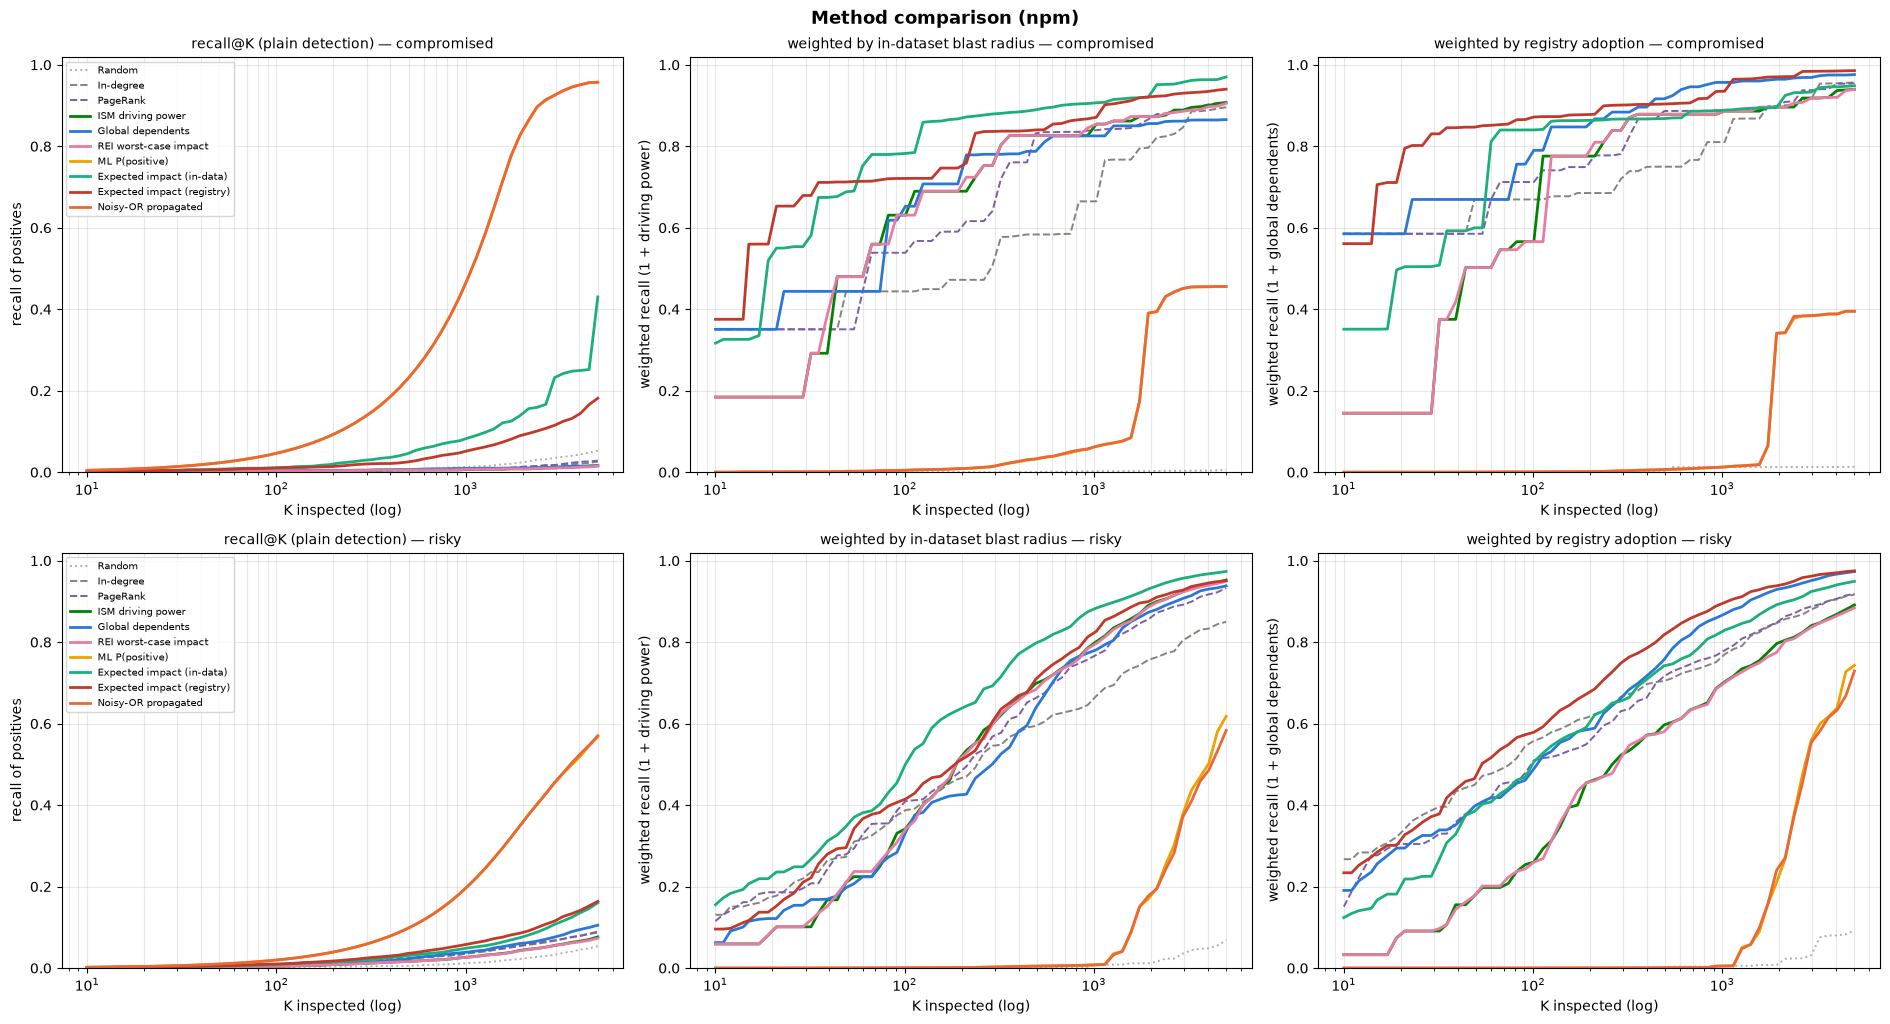

In [8]:
K_GRID_MAX = min(5000, min(int(v["keep"].sum()) for v in VIEWS.values()))
K_GRID = np.unique(np.round(np.logspace(1, np.log10(K_GRID_MAX), 60)).astype(int))
n_v = len(VIEWS)
fig, axes = plt.subplots(n_v, 3, figsize=(19, 5.2 * n_v), squeeze=False)
for i, vname in enumerate(VIEWS):
    panels = [(0, "recall@K (plain detection)", "recall of positives"),
              (2, "weighted by in-dataset blast radius", "weighted recall (1 + driving power)"),
              (3, "weighted by registry adoption", "weighted recall (1 + global dependents)")]
    for ax, (which, ttl, ylab) in zip(axes[i], panels):
        for name in METHODS_BY_VIEW[vname]:
            c, ls = METHOD_STYLE[name]
            arr = curves[(vname, name)][which]
            ax.plot(K_GRID, arr[K_GRID - 1], color=c, ls=ls,
                    lw=1.4 if ls != "-" else 2.0, label=name)
        ax.set_xscale("log"); ax.set_xlabel("K inspected (log)")
        ax.set_ylabel(ylab); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3, which="both")
        ax.set_title(f"{ttl} — {vname}", fontsize=10)
    axes[i][0].legend(fontsize=7, loc="upper left")
fig.suptitle(f"Method comparison ({ECO_TITLE})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "recall_at_k.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

### Cross-currency check — is the expected-impact win circular?

In [9]:
cross_rows = []
for vname in VIEWS:
    sub = metrics[metrics.view == vname].set_index("method")
    cols = [c for c in ["wrecall_ds@1000", "wrecall_rw@1000"] if c in sub.columns]
    if len(cols) < 2:
        print(f"[{vname}] both weighted recalls unavailable at K=1000 — skipped")
        continue
    OWN = {"Expected impact (in-data)": "wrecall_ds@1000",
           "Expected impact (registry)": "wrecall_rw@1000"}
    for m in sub.index:
        cross_rows.append({"view": vname, "method": m,
                           "wrecall_ds@1000": float(sub.loc[m, "wrecall_ds@1000"]),
                           "wrecall_rw@1000": float(sub.loc[m, "wrecall_rw@1000"]),
                           "optimises": OWN.get(m, "-")})
    win_ds, win_rw = sub["wrecall_ds@1000"].idxmax(), sub["wrecall_rw@1000"].idxmax()
    print("")
    print(f"=== {vname} ===")
    print(sub[cols].sort_values(cols[1], ascending=False).to_string(float_format="{:.4f}".format))
    print(f"  in-dataset currency won by : {win_ds}"
          f"{'   <- optimises this one (circular)' if OWN.get(win_ds)=='wrecall_ds@1000' else ''}")
    print(f"  registry currency won by   : {win_rw}"
          f"{'   <- optimises this one (circular)' if OWN.get(win_rw)=='wrecall_rw@1000' else ''}")
    for m, own in OWN.items():
        if m not in sub.index:
            continue
        other = "wrecall_rw@1000" if own == "wrecall_ds@1000" else "wrecall_ds@1000"
        rank = int((sub[other] > sub.loc[m, other]).sum()) + 1
        print(f"  {m:28s} ranks {rank}/{len(sub)} on the currency it does NOT optimise "
              f"({other} = {sub.loc[m, other]:.4f})")
if cross_rows:
    pd.DataFrame(cross_rows).to_csv(OUT_DIR / "cross_currency.csv", index=False)


=== compromised ===
                            wrecall_ds@1000  wrecall_rw@1000
method                                                      
Global dependents                    0.8256           0.9568
Expected impact (registry)           0.8701           0.9351
Expected impact (in-data)            0.9066           0.8887
PageRank                             0.8394           0.8885
REI worst-case impact                0.8545           0.8863
ISM driving power                    0.8545           0.8863
In-degree                            0.6648           0.8103
Noisy-OR propagated                  0.0628           0.0128
ML P(positive)                       0.0627           0.0127
Random                               0.0023           0.0125
  in-dataset currency won by : Expected impact (in-data)   <- optimises this one (circular)
  registry currency won by   : Global dependents
  Expected impact (in-data)    ranks 3/10 on the currency it does NOT optimise (wrecall_rw@1000 = 0.8887)


## 8. Per-level AUROC and rank agreement

In [10]:
pl_rows = []
for vname, v in VIEWS.items():
    keep = v["keep"]; y = v["y"]; bk = bucket_pkg[keep]
    for b in BUCKET_ORDER:
        m = bk == b
        if m.sum() == 0:
            continue
        yb = y[m]
        if yb.sum() < MIN_PER_CLASS or (yb == 0).sum() < MIN_PER_CLASS:
            continue
        for name, s_full in METHODS_BY_VIEW[vname].items():
            pl_rows.append({"view": vname, "level_bucket": b, "method": name,
                            "n": int(m.sum()), "n_positive": int(yb.sum()),
                            "ROC-AUC": float(roc_auc_score(yb, np.asarray(s_full)[keep][m]))})
per_level = pd.DataFrame(pl_rows)
per_level.to_csv(OUT_DIR / "method_metrics_per_level.csv", index=False)
if len(per_level):
    for vname in VIEWS:
        sub = per_level[per_level.view == vname]
        if len(sub):
            print(f"\n=== AUROC by Warfield level bucket — {vname} ===")
            print(sub.pivot(index="level_bucket", columns="method", values="ROC-AUC")
                  .reindex([b for b in BUCKET_ORDER if b in set(sub.level_bucket)])
                  .to_string(float_format="{:.3f}".format))
else:
    print(f"No level bucket carries >={MIN_PER_CLASS} of each class — per-level AUROC skipped.")


=== AUROC by Warfield level bucket — compromised ===
method        Expected impact (in-data)  Expected impact (registry)  Global dependents  ISM driving power  In-degree  ML P(positive)  Noisy-OR propagated  PageRank  REI worst-case impact  Random
level_bucket                                                                                                                                                                                      
isolated                          0.996                       0.874              0.023              0.500      0.500           0.996                0.996     0.500                  0.023   0.503
0                                 0.959                       0.888              0.306              0.469      0.477           0.980                0.980     0.523                  0.357   0.520
1                                 0.946                       0.839              0.166              0.404      0.411           0.985                0.986     0.403   

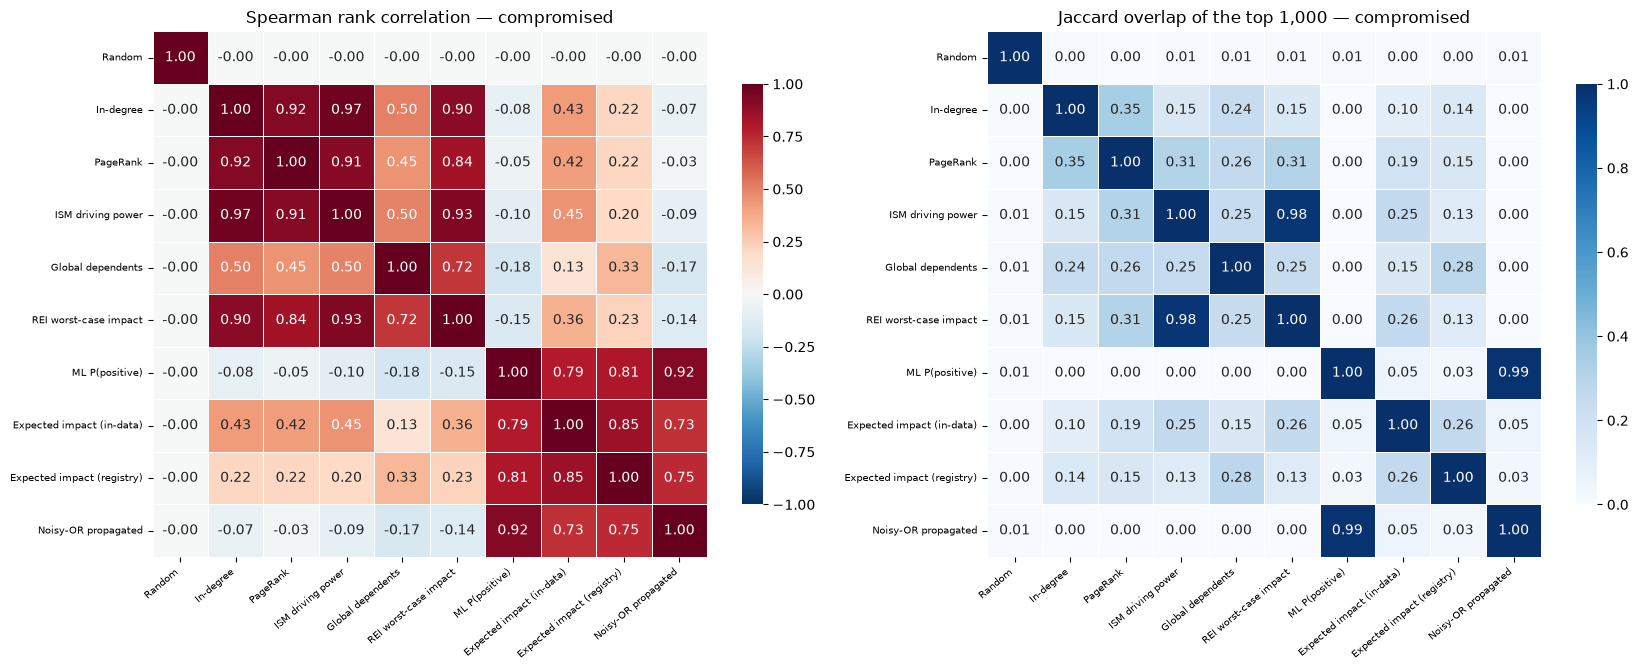

[compromised] Spearman(ML, ISM driving) = -0.103 | Spearman(ML, Global dependents) = -0.182


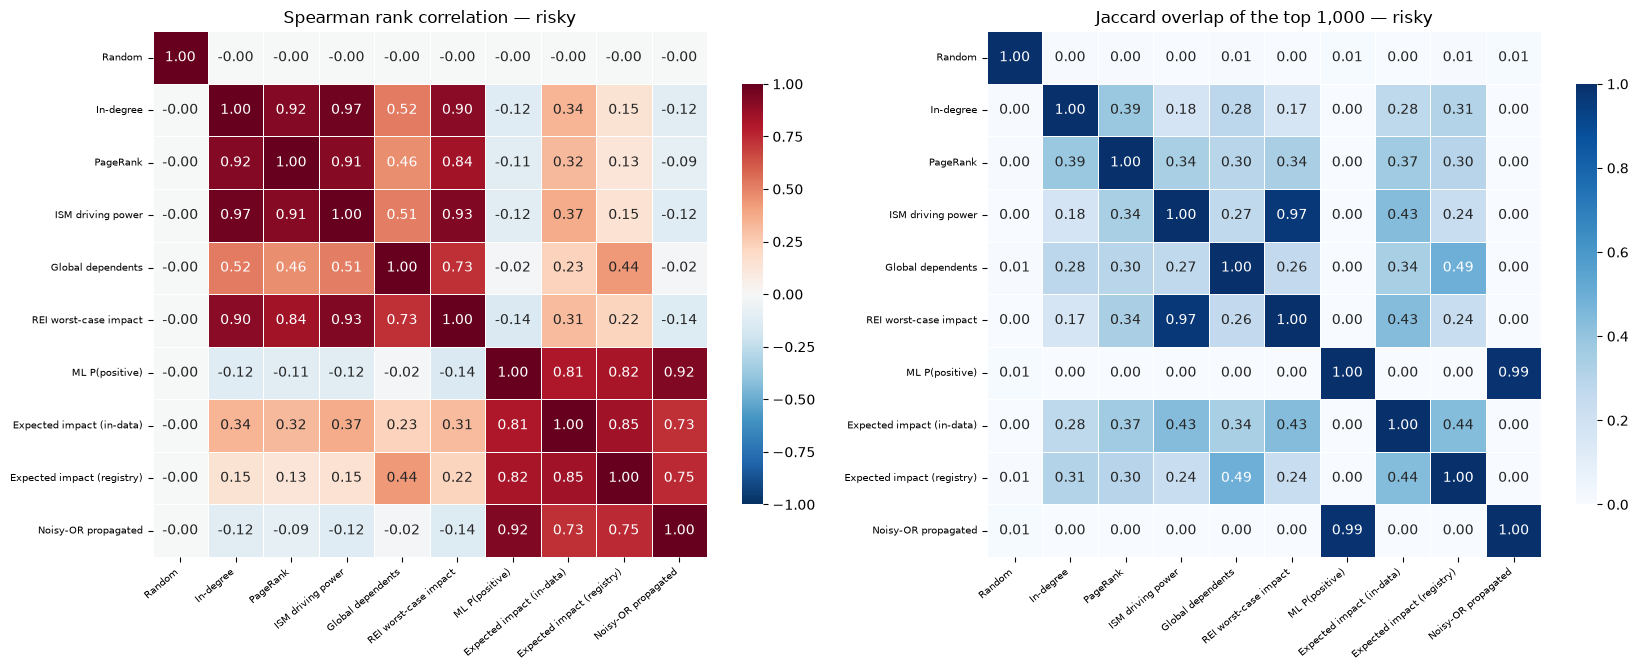

[risky] Spearman(ML, ISM driving) = -0.116 | Spearman(ML, Global dependents) = -0.020


In [11]:
for vname, v in VIEWS.items():
    M = METHODS_BY_VIEW[vname]; keep = v["keep"]
    names = list(M)
    mat = pd.DataFrame({n: np.asarray(M[n])[keep] for n in names})
    spear = mat.corr(method="spearman")
    spear.to_csv(OUT_DIR / f"rank_spearman_{vname}.csv")
    k_top = min(1000, int(keep.sum()))
    tops = {n: set(np.lexsort((tiebreak[keep], -np.asarray(M[n])[keep]))[:k_top]) for n in names}
    jac = pd.DataFrame([[len(tops[a] & tops[b]) / len(tops[a] | tops[b]) for b in names]
                        for a in names], index=names, columns=names)
    jac.to_csv(OUT_DIR / f"topk_jaccard_{vname}.csv")

    fig, axes = plt.subplots(1, 2, figsize=(17, 6.8))
    sns.heatmap(spear, ax=axes[0], annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
                center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
    axes[0].set_title(f"Spearman rank correlation — {vname}")
    sns.heatmap(jac, ax=axes[1], annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    axes[1].set_title(f"Jaccard overlap of the top {k_top:,} — {vname}")
    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=7)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"rank_agreement_{vname}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"[{vname}] Spearman(ML, ISM driving) = "
          f"{spear.loc['ML P(positive)','ISM driving power']:+.3f} | "
          f"Spearman(ML, Global dependents) = "
          f"{spear.loc['ML P(positive)','Global dependents']:+.3f}")

## 9. Summary

In [13]:
summary = {"ecosystem": ECO, "views": ",".join(VIEWS),
            "n_packages": N, "n_edges": int(len(src)),
            "spearman_impact_currencies": round(rho, 4),
            "runtime_min": (time.time() - t_nb) / 60}
for vname in VIEWS:
    sub = metrics[metrics.view == vname].set_index("method")
    for col, tag in [("PR-AUC", "prauc"), ("ROC-AUC", "auroc")]:
        summary[f"{vname}_best_{tag}_method"] = sub[col].idxmax()
        summary[f"{vname}_best_{tag}"] = round(float(sub[col].max()), 4)
    for wc in ["wrecall_ds@1000", "wrecall_rw@1000"]:
        if wc in sub.columns:
            summary[f"{vname}_best_{wc}_method"] = sub[wc].idxmax()
            summary[f"{vname}_best_{wc}"] = round(float(sub[wc].max()), 4)
    summary[f"{vname}_ISM_auroc"] = round(float(sub.loc["ISM driving power", "ROC-AUC"]), 4)
    summary[f"{vname}_ML_auroc"] = round(float(sub.loc["ML P(positive)", "ROC-AUC"]), 4)
pd.Series(summary).to_frame("value").to_csv(OUT_DIR / "summary.csv")
print(pd.Series(summary).to_string())

ecosystem                                                         npm
views                                               compromised,risky
n_packages                                                     101350
n_edges                                                        388416
spearman_impact_currencies                                     0.5114
runtime_min                                                  1.599781
compromised_best_prauc_method                     Noisy-OR propagated
compromised_best_prauc                                         0.9289
compromised_best_auroc_method                     Noisy-OR propagated
compromised_best_auroc                                         0.9926
compromised_best_wrecall_ds@1000_method     Expected impact (in-data)
compromised_best_wrecall_ds@1000                               0.9066
compromised_best_wrecall_rw@1000_method             Global dependents
compromised_best_wrecall_rw@1000                               0.9568
compromised_ISM_auro